Initialize KAN

In [33]:
from kan import *
import torch
torch.set_default_dtype(torch.float64)
device = torch.device('cpu')
print(device)


cpu


Create dataset

In [34]:
from kan.utils import create_dataset
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
dataset = create_dataset(f, n_var=2, device=device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

In [36]:
np.savez('standard_dataset', **dataset)

In [43]:
import torch
from  kan import MultKAN
def custom_runner(width, dataset, grids=[5,10,20], steps=20, lamb=0.001, prune_round=3, refine_round=3, edge_th=1e-2, node_th=1e-2, metrics=None, seed=1):

    result = {}
    result['test_loss'] = []
    result['c'] = []
    result['G'] = []
    result['id'] = []
    if metrics != None:
        for i in range(len(metrics)):
            result[metrics[i].__name__] = []

    def collect(evaluation):
        result['test_loss'].append(evaluation['test_loss'])
        result['c'].append(evaluation['n_edge'])
        result['G'].append(evaluation['n_grid'])
        result['id'].append(f'{model.round}.{model.state_id}')
        if metrics != None:
            for i in range(len(metrics)):
                result[metrics[i].__name__].append(metrics[i](model, dataset).item())

    model = KAN(width=width, grid=grids[0], seed=seed)
    model.fit(dataset, steps=steps, lamb=lamb)
    model = model.prune(edge_th=edge_th, node_th=node_th)
    evaluation = model.evaluate(dataset)
    collect(evaluation)

    for j in range(1, refine_round):
        model = model.refine(grids[j])
        model.fit(dataset, steps=steps)
        evaluation = model.evaluate(dataset)
        collect(evaluation)

    for key in list(result.keys()):
        result[key] = np.array(result[key])

    return result

In [ ]:
=grids = [3, 5, 10, 20, 50, 100, 200, 500, 1000]
results = custom_runner(width=[2, 1 ,1], dataset=dataset, steps=200, grids=grids, prune_round=1, refine_round=len(grids))

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.07e-01 | test_loss: 5.45e-01 | reg: 7.64e+00 | : 100%|█| 500/500 [03:27<00:00,  2.41


saving model version 0.1
saving model version 0.2
saving model version 0.3


| train_loss: 5.05e-01 | test_loss: 5.44e-01 | reg: 7.63e+00 | : 100%|█| 500/500 [03:39<00:00,  2.28


saving model version 0.4
saving model version 0.5


...

saving model version 0.6
saving model version 0.7


| train_loss: 4.15e-01 | test_loss: 5.72e-01 | reg: 6.99e+00 | : 100%|█| 500/500 [03:59<00:00,  2.08


saving model version 0.8
saving model version 0.9


| train_loss: 3.44e-01 | test_loss: 4.98e-01 | reg: 6.81e+00 | :  80%|▊| 399/500 [03:38<00:55,  1.82


KeyboardInterrupt: 

In [ ]:
np.savez('standard-default', **results)

In [ ]:
def plot(x, y):
    
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, color='blue', marker='o', linestyle='-', label='Data Points')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Complexity (Parameters/Edges)')
    plt.ylabel('Test Loss (MSE)')
    plt.title('KAN Trade-off: Complexity vs. Test Loss')
    plt.xlim(1e1, 1e5)
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)

    plt.show()

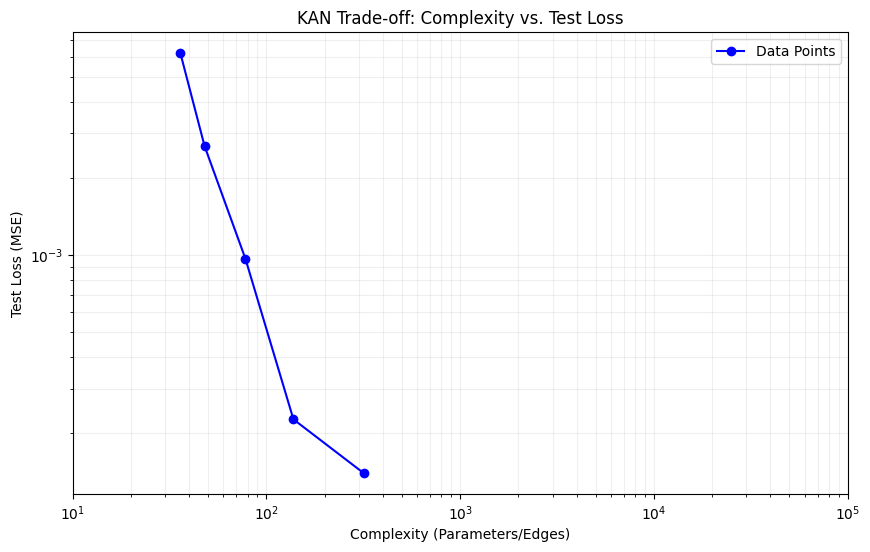

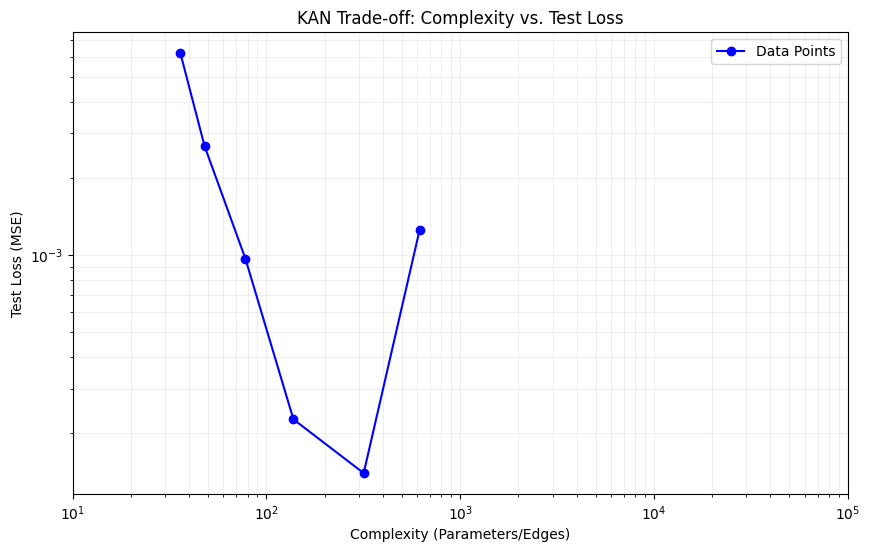

In [ ]:
complexity = results['c'] * (results['G'] + 3)
test_loss = results['test_loss']

# x_pf, y_pf, pf_id = experiment.pareto_frontier(complexity, test_loss)

# sort_idx = np.argsort(x_pf)
# x_pf = x_pf[sort_idx]
# y_pf = y_pf[sort_idx]

# plot(x_pf, y_pf)
plot(complexity, test_loss)